# OpenAI互換VLMによる物体検出

このNotebookでは、OpenAI互換のChat Completions APIに画像を渡し、画像内の主要物体をバウンディングボックスで可視化します。

> **注意**: VLMが返す座標とconfidenceは専用の物体検出モデルによる値ではありません。confidenceは参考値としてのみ利用してください。

## 1. ライブラリのインポート

In [1]:
import base64
import json
import mimetypes
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from PIL import Image, ImageDraw, ImageFont

## 2. APIと入力画像の設定

以下の環境変数を設定してから実行してください: `VLM_API_KEY`、`VLM_BASE_URL`、`VLM_MODEL`。

モデル: gpt-5.6-luna
画像サイズ: 1448 x 1086


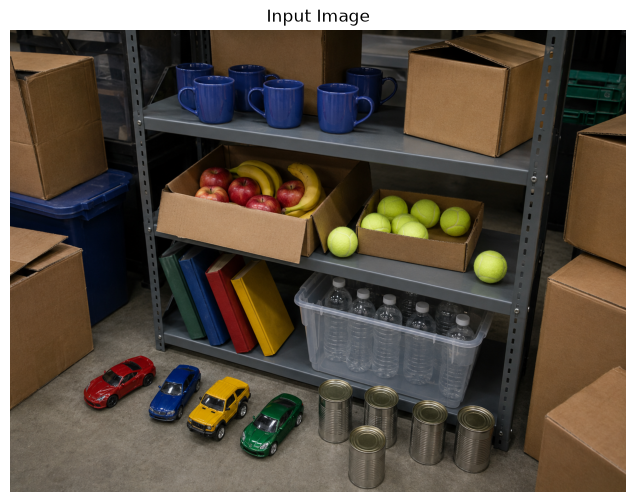

In [2]:
load_dotenv(dotenv_path=Path(".env"), override=False)

api_key = os.environ.get("VLM_API_KEY")
base_url = os.environ.get("VLM_BASE_URL")
model_name = os.environ.get("VLM_MODEL")

missing = [
    name
    for name, value in {
        "VLM_API_KEY": api_key,
        "VLM_MODEL": model_name,
    }.items()
    if not value
]
if missing:
    raise EnvironmentError(
        "環境変数が未設定です: " + ", ".join(missing) +
        "。README.md の API設定 を確認してください。"
    )

client = OpenAI(api_key=api_key)
image_path = Path("../assets/test1.png")
if not image_path.is_file():
    raise FileNotFoundError(f"入力画像が見つかりません: {image_path.resolve()}")

image = Image.open(image_path).convert("RGB")
print(f"モデル: {model_name}")
print(f"画像サイズ: {image.size[0]} x {image.size[1]}")
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

## 3. VLMに物体検出を依頼

座標は画像幅・高さをそれぞれ1000とした正規化座標で返させます。API実装ごとの構造化出力対応に依存しないよう、JSONのみを返すようプロンプトで指定します。

In [3]:
mime_type = mimetypes.guess_type(image_path.name)[0] or "image/png"
image_base64 = base64.b64encode(image_path.read_bytes()).decode("ascii")
image_url = f"data:{mime_type};base64,{image_base64}"

system_prompt = """
あなたは画像内の物体を検出するアシスタントです。
画像内で視認できる主要な物体をできる限り網羅し、同じ物体を重複して返さないでください。
各物体について、意味の分かる短いラベル、0から1の参考confidence、物体を囲む矩形を返してください。
矩形は画像の幅と高さをそれぞれ1000とする正規化座標 [x1, y1, x2, y2] です。
返答は説明・Markdown・コードフェンスを含めず、必ず次のJSONオブジェクトだけにしてください。
{"detections":[{"label":"object name","confidence":0.0,"bbox_1000":[0,0,0,0]}]}
物体が見つからない場合は {"detections":[]} を返してください。
"""

try:
    completion = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": "この画像を検出してください。"},
                    {"type": "image_url", "image_url": {"url": image_url}},
                ],
            },
        ],
    )
except Exception as error:
    print(error)
    raise RuntimeError(
        "VLM APIの呼び出しに失敗しました。URL・モデル名・認証情報と、画像入力対応を確認してください。"
    ) from error

raw_response = completion.choices[0].message.content or ""
print(raw_response)

{"detections":[{"label":"metal shelving unit","confidence":0.99,"bbox_1000":[186,0,872,921]},{"label":"cardboard box","confidence":0.97,"bbox_1000":[0,49,159,370]},{"label":"cardboard box","confidence":0.96,"bbox_1000":[323,0,571,190]},{"label":"cardboard box","confidence":0.98,"bbox_1000":[644,5,866,275]},{"label":"cardboard box","confidence":0.96,"bbox_1000":[897,183,1000,521]},{"label":"cardboard box","confidence":0.96,"bbox_1000":[0,432,140,828]},{"label":"cardboard box","confidence":0.96,"bbox_1000":[866,503,1000,1000]},{"label":"cardboard box","confidence":0.95,"bbox_1000":[882,731,1000,1000]},{"label":"blue storage bin","confidence":0.98,"bbox_1000":[0,305,202,630]},{"label":"blue ceramic mug","confidence":0.98,"bbox_1000":[268,72,331,202]},{"label":"blue ceramic mug","confidence":0.98,"bbox_1000":[354,76,435,201]},{"label":"blue ceramic mug","confidence":0.98,"bbox_1000":[545,79,625,222]},{"label":"blue ceramic mug","confidence":0.98,"bbox_1000":[273,100,365,205]},{"label":"blu

## 4. 応答の検証とピクセル座標への変換

In [4]:
def parse_detection_response(text):
    fenced = re.search(r"```(?:json)?\s*(.*?)```", text, flags=re.DOTALL | re.IGNORECASE)
    candidate = fenced.group(1) if fenced else text
    if not fenced:
        start, end = candidate.find("{"), candidate.rfind("}")
        candidate = candidate[start:end + 1] if start >= 0 and end >= start else candidate
    try:
        payload = json.loads(candidate.strip())
    except json.JSONDecodeError as error:
        raise ValueError("VLMの応答をJSONとして解釈できません。上の応答を確認してください。") from error
    if not isinstance(payload, dict) or not isinstance(payload.get("detections"), list):
        raise ValueError("VLM応答には detections 配列が必要です。")
    return payload["detections"]

def normalize_detections(raw_detections, image_width, image_height):
    valid = []
    for index, item in enumerate(raw_detections):
        if not isinstance(item, dict):
            print(f"検出 {index} を無視しました: オブジェクトではありません。")
            continue
        label = str(item.get("label", "")).strip()
        bbox = item.get("bbox_1000")
        try:
            values = [float(value) for value in bbox]
            if len(values) != 4 or not label:
                raise ValueError
        except (TypeError, ValueError):
            print(f"検出 {index} を無視しました: label または bbox_1000 が不正です。")
            continue
        x1, y1, x2, y2 = [max(0.0, min(1000.0, value)) for value in values]
        x1, x2 = sorted((x1, x2))
        y1, y2 = sorted((y1, y2))
        if x1 == x2 or y1 == y2:
            print(f"検出 {index} を無視しました: 面積が0の矩形です。")
            continue
        try:
            confidence = float(item.get("confidence", 0.0))
        except (TypeError, ValueError):
            confidence = 0.0
        valid.append({
            "label": label,
            "confidence": max(0.0, min(1.0, confidence)),
            "x1": round(x1 / 1000 * image_width, 1),
            "y1": round(y1 / 1000 * image_height, 1),
            "x2": round(x2 / 1000 * image_width, 1),
            "y2": round(y2 / 1000 * image_height, 1),
        })
    return valid

raw_detections = parse_detection_response(raw_response)
detections = normalize_detections(raw_detections, *image.size)
print(f"有効な検出数: {len(detections)}")

有効な検出数: 49


## 5. 検出結果の可視化と集計

confidenceはVLMの参考値です。しきい値による自動除外は行わず、結果を目視で確認してください。

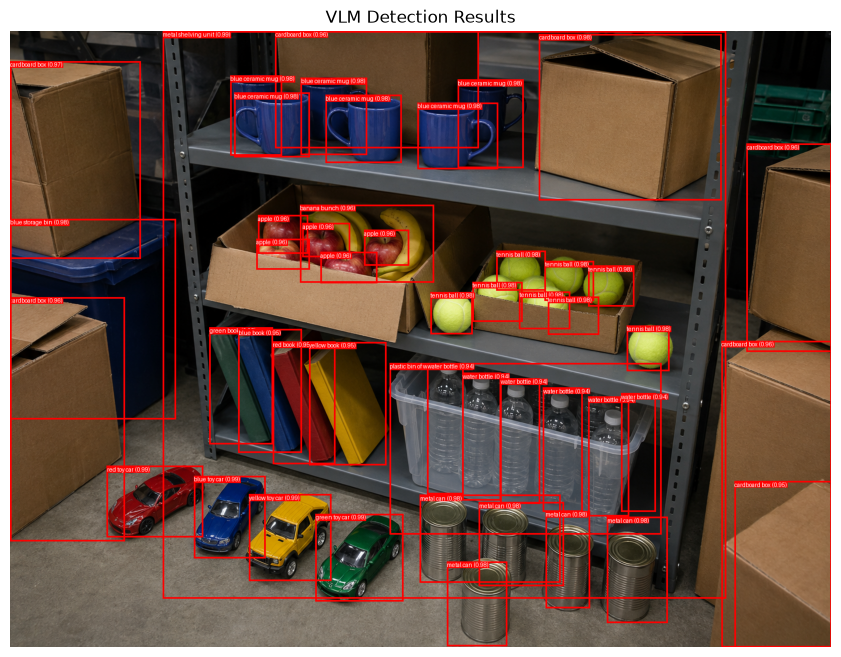

,label,confidence,x1,y1,x2,y2
0,metal shelving unit,0.99,269.3,0.0,1262.7,1000.2
1,cardboard box,0.97,0.0,53.2,230.2,401.8
2,cardboard box,0.96,467.7,0.0,826.8,206.3
3,cardboard box,0.98,932.5,5.4,1254.0,298.7
4,cardboard box,0.96,1298.9,198.7,1448.0,565.8
5,cardboard box,0.96,0.0,469.2,202.7,899.2
6,cardboard box,0.96,1254.0,546.3,1448.0,1086.0
7,cardboard box,0.95,1277.1,793.9,1448.0,1086.0
8,blue storage bin,0.98,0.0,331.2,292.5,684.2
9,blue ceramic mug,0.98,388.1,78.2,479.3,219.4


ラベル別の検出数


,label,検出数
0,tennis ball,8
1,cardboard box,7
2,water bottle,6
3,blue ceramic mug,6
4,metal can,5
5,apple,5
6,banana bunch,1
7,blue storage bin,1
8,blue toy car,1
9,blue book,1


In [5]:
annotated = image.copy()
draw = ImageDraw.Draw(annotated)
font = ImageFont.load_default()

for detection in detections:
    x1, y1, x2, y2 = (detection[key] for key in ("x1", "y1", "x2", "y2"))
    draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
    text = f"{detection['label']} ({detection['confidence']:.2f})"
    text_box = draw.textbbox((x1, y1), text, font=font)
    draw.rectangle(text_box, fill="red")
    draw.text((x1, y1), text, fill="white", font=font)

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("VLM Detection Results")
plt.show()

df = pd.DataFrame(detections, columns=["label", "confidence", "x1", "y1", "x2", "y2"])
display(df)

if df.empty:
    print("有効な検出結果はありません。")
else:
    counts = df.groupby("label").size().sort_values(ascending=False).rename("検出数").reset_index()
    print("ラベル別の検出数")
    display(counts)